The purpose of this notebook is to generate plots for the timeseries and power spectrum figure we will use in figure 2.

In [1]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import xarray as xr
import numpy as np
from pathlib import Path
from astropy.timeseries import LombScargle
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs, calculate_mean_and_ci
from methane_noise_forcing.naming import (
    generate_noise_realization_name,
    generate_firn_smoothing_name,
)
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant
)
from methane_noise_forcing.core import sample_ensemble_series

plt.rcParams.update(matplotlib_rcparams)

In [2]:
## figure settings
fig_width = fig_width_options["one_column"] # inches, aim for single column

colors = {
    "obs": "k",
    "red_noise": colors_vibrant["blue"],
    "red_noise_filtered": colors_vibrant["magenta"]
}
alphas = {
    "red_noise": 0.15,
    "red_noise_filtered": 0.2
}

In [3]:
# choose smoothing filter and sampling location
site_name = "wdc06a" # wdc05a, wdc06a, gisp2, or neem
if site_name == "wdc05a" or site_name == "wdc06a":
    filter_name = "wais"
else:
    filter_name = site_name

with initialize(version_base=None, config_path="../../configs"):
    cfg = compose(config_name="config", overrides=[
        f"+noise=white_noise_ar1",
        # f"+noise=two_timescale_ar1_100",
        f"+firn_kernel=firn_model_{filter_name}",
        f"+sampling={site_name}"
    ])

# load observations and psd

In [4]:
## obs and detrending
data_obs = io.load_observational_data(site_name, **cfg.io[site_name].input)
# detrend data
data_obs_detrended = detrend_obs(site_name, data_obs)
# convert to dataset with 'ch4' and 'ch4_detrended'
data_obs = xr.Dataset(
    {
        "ch4": (["time"], data_obs.ch4),
        "ch4_detrended": (["time"], data_obs_detrended.ch4),
    },
    coords={
        "time": data_obs.gas_age
    }
)
# invert time axis
data_obs = data_obs.isel(time=slice(None, None, -1))

## power spectrum
psd_obs = xr.open_dataset(cfg.io[site_name].power_spectra_path)

2025-08-26 22:25:35,539 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2025-08-26 22:25:35,546 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2


Text(0.5, 0, 'Time (year CE)')

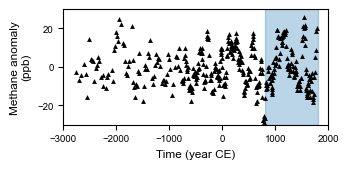

In [5]:
## plot panel A, which is a timeseries of the obs
ylim = (-30, 30)
xlim = (-3000, 2000)
time_shading = (800, 1800)

fig, ax = plt.subplots(figsize=(fig_width, 1.5))

ax.plot(
    data_obs.time,
    data_obs["ch4_detrended"],
    color=colors["obs"],
    marker='^',
    markersize=3.5,
    markeredgecolor="None",
    linestyle="None",
)
# add shading for period in figure 2
ax.axvspan(*time_shading, color="tab:blue", alpha=0.3)

ax.set_ylim(ylim)
ax.set_xlim(xlim)
ax.set_ylabel("Methane anomaly\n(ppb)")
ax.set_xlabel("Time (year CE)")

## load noise and calculate psd
Just load unsmoothed ar1 and smoothed ar1, sample both in this notebook because it's fast

In [6]:
## resolve paths
noise_name = generate_noise_realization_name(cfg)
firn_name = generate_firn_smoothing_name(cfg)
input_dir = Path(cfg.paths.noise_realizations_root) / noise_name

# raw noise
noise_raw = xr.open_dataset(input_dir / f"{noise_name}.nc")
# smoothed noise
noise_smoothed = xr.open_dataset(input_dir / firn_name / f"smoothed_{noise_name}.nc")

In [7]:
## sample at same points as obs
noise_raw_sampled = sample_ensemble_series(
    da=noise_raw["ch4"],
    core_time=data_obs.time,
    core_offset_flag="start",
    series_offset=150
)
noise_smoothed_sampled = sample_ensemble_series(
    da=noise_smoothed["ch4"],
    core_time=data_obs.time,
    core_offset_flag="start",
    series_offset=150
)

# scale by ensemble mean variance
var_obs = np.var(data_obs["ch4_detrended"], ddof=1)
var_raw_sampled = noise_raw_sampled.var(ddof=1, dim="time")
var_smoothed_sampled = noise_smoothed_sampled.var(ddof=1, dim="time")
print(f"Observed variance: {var_obs:0.1f} ppb^2")
print(f"Raw sampled variance: {var_raw_sampled.mean():0.1f} ± {var_raw_sampled.std():0.1f} ppb^2")
print(f"Smoothed sampled variance: {var_smoothed_sampled.mean():0.1f} ± {var_smoothed_sampled.std():0.1f} ppb^2")
noise_raw_sampled *= np.sqrt(var_obs/var_raw_sampled.mean())
noise_smoothed_sampled *= np.sqrt(var_obs/var_smoothed_sampled.mean())

## calculate psd
psd_raw = []
psd_smooth = []
for idx_ens in noise_raw_sampled.ensemble.values:
    # red noise raw
    frequencies, power_spectrum = LombScargle(
        noise_raw_sampled.time.values, 
        noise_raw_sampled.sel(ensemble=idx_ens).values
        ).autopower(
            normalization="psd", 
            samples_per_peak=1,
    )
    psd_raw.append(power_spectrum)

    # red noise smoothed
    frequencies, power_spectrum = LombScargle(
        noise_smoothed_sampled.time.values, 
        noise_smoothed_sampled.sel(ensemble=idx_ens).values
        ).autopower(
            normalization="psd", 
            samples_per_peak=1,
    )
    psd_smooth.append(power_spectrum)

# combine into dataset
psd_noise = xr.Dataset(
    {
        "red_noise": (["ensemble", "frequency"], np.array(psd_raw)),
        "red_noise_filtered": (["ensemble", "frequency"], np.array(psd_smooth)),
    },
    coords={
        "frequency": frequencies,
        "ensemble": noise_raw_sampled.ensemble.values,
    }
)

Observed variance: 103.3 ppb^2
Raw sampled variance: 317.4 ± 27.5 ppb^2
Smoothed sampled variance: 117.3 ± 16.9 ppb^2


[Text(0, 0.1, '0.1'),
 Text(0, 1.0, '1'),
 Text(0, 10.0, '10'),
 Text(0, 100.0, '100'),
 Text(0, 1000.0, '1000')]

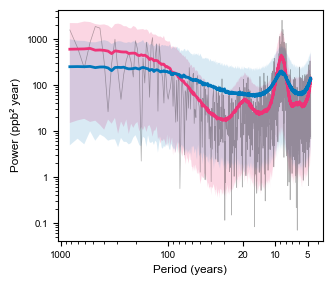

In [8]:
## plot psd
# upper bound mask
period_high = 1000
tick_labels = [1000, 100, 20, 10, 5]
mask = frequencies >= 1/period_high
frequencies_to_plot = frequencies[mask]

fig, ax = plt.subplots(figsize=(fig_width, 3))

# observed
ax.plot(
    1 / psd_obs.sel(frequency=frequencies_to_plot).frequency,
    psd_obs.sel(frequency=frequencies_to_plot).power_spectrum_detrended_unnormalized,
    color=colors["obs"],
    linewidth=0.5,
    alpha=0.3
)
# plot mean and confidence intervals for sampled noise
for key in ["red_noise_filtered", "red_noise"]:
    mean, ci_low, ci_high = calculate_mean_and_ci(psd_noise.sel(frequency=frequencies_to_plot)[key])
    ax.plot(
        1 / psd_noise.sel(frequency=frequencies_to_plot).frequency,
        mean,
        color=colors[key],
        linewidth=2
    )
    ax.fill_between(
        1 / psd_noise.sel(frequency=frequencies_to_plot).frequency,
        ci_low,
        ci_high,
        color=colors[key],
        alpha=alphas[key],
        edgecolor="none"
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb² year)")
ax.set_xticks(tick_labels)
ax.set_xticklabels([f"{tick}" for tick in tick_labels])

# set y-axis ticks to plain numbers
y_tick_labels = [0.1, 1, 10, 100, 1000]
ax.set_yticks(y_tick_labels)
ax.set_yticklabels([str(y) for y in y_tick_labels])

# putting it all together

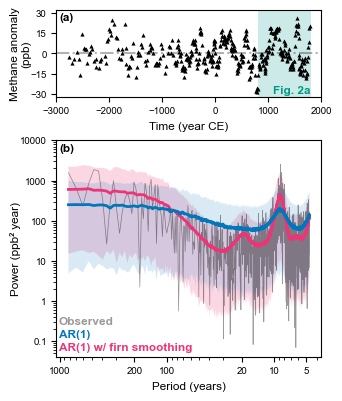

In [9]:
# timeseries parameters
ylim = (-32, 32)
yticks = [-30, -15, 0, 15, 30]
xlim = (-3000, 2000)
time_shading = (800, 1800)
# psd parameters
period_high = 1000
tick_labels = [1000, 200, 100, 20, 10, 5]
mask = frequencies >= 1/period_high
frequencies_to_plot = frequencies[mask]

fig = plt.figure(figsize=(fig_width, 4.5))
gs = GridSpec(
    nrows=3,
    ncols=1,
    figure=fig,
    height_ratios=[0.4, 0.15, 1],
    hspace=0.05
)
ax_ts = fig.add_subplot(gs[0, 0]) # timeseries
ax_psd = fig.add_subplot(gs[2, 0]) # power spectral density

## timeseries
ax_ts.plot(
    data_obs.time,
    data_obs["ch4_detrended"],
    color=colors["obs"],
    marker='^',
    markersize=3,
    markeredgecolor="None",
    linestyle="None",
)
# add shading for period in figure 2
ax_ts.axvspan(*time_shading, facecolor=colors_vibrant["teal"], alpha=0.2, edgecolor="none")
ax_ts.axhline(0, color="k", linestyle="-.", alpha=0.3)

ax_ts.set_ylim(ylim)
ax_ts.set_yticks(yticks)
ax_ts.set_xlim(xlim)
ax_ts.set_ylabel("Methane anomaly\n(ppb)", labelpad=-1)
ax_ts.set_xlabel("Time (year CE)")

# (3) Top left bold (a)
ax_ts.text(
    0.01, 0.97,
    "(a)",
    transform=ax_ts.transAxes,
    va="top", ha="left",
    fontweight="bold"
)

# (4) Right edge of axvspan, right aligned, bottom
ax_ts.text(
    time_shading[1], ylim[0]+1,
    "Fig. 2a",
    va="bottom", ha="right",
    fontweight="bold",
    color=colors_vibrant["teal"]
)

## power spectral density
# observed
ax_psd.plot(
    1 / psd_obs.sel(frequency=frequencies_to_plot).frequency,
    psd_obs.sel(frequency=frequencies_to_plot).power_spectrum_detrended_unnormalized,
    color=colors["obs"],
    linewidth=0.5,
    alpha=0.4
)
# plot mean and confidence intervals for sampled noise
for key in ["red_noise_filtered", "red_noise"]:
    mean, ci_low, ci_high = calculate_mean_and_ci(psd_noise.sel(frequency=frequencies_to_plot)[key])
    ax_psd.plot(
        1 / psd_noise.sel(frequency=frequencies_to_plot).frequency,
        mean,
        color=colors[key],
        linewidth=2
    )
    ax_psd.fill_between(
        1 / psd_noise.sel(frequency=frequencies_to_plot).frequency,
        ci_low,
        ci_high,
        color=colors[key],
        alpha=alphas[key],
        edgecolor="none"
    )

ax_psd.set_xscale('log')
ax_psd.set_yscale('log')
ax_psd.invert_xaxis()
ax_psd.set_xlabel("Period (years)")
ax_psd.set_ylabel("Power (ppb² year)", labelpad=-1)
ax_psd.set_xticks(tick_labels)
ax_psd.set_xticklabels([f"{tick}" for tick in tick_labels])

# set y-axis ticks to plain numbers
y_tick_labels = [0.1, 1, 10, 100, 1000, 10000]
ax_psd.set_yticks(y_tick_labels)
ax_psd.set_yticklabels([str(y) for y in y_tick_labels])

# (2) Bottom left legend text
legend_x = 0.01
legend_y_start = 0.02
legend_dy = 0.06
ax_psd.text(
    legend_x-0.003, legend_y_start + 2*legend_dy,
    "Observed",
    color=colors["obs"],
    alpha=0.4,
    fontweight="bold",
    ha="left", va="bottom",
    transform=ax_psd.transAxes
)
ax_psd.text(
    legend_x, legend_y_start + legend_dy,
    "AR(1)",
    color=colors["red_noise"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=ax_psd.transAxes
)
ax_psd.text(
    legend_x, legend_y_start,
    "AR(1) w/ firn smoothing",
    color=colors["red_noise_filtered"],
    fontweight="bold",
    ha="left", va="bottom",
    transform=ax_psd.transAxes
)

# (3) Top left bold (b)
ax_psd.text(
    0.01, 0.985,
    "(b)",
    transform=ax_psd.transAxes,
    va="top", ha="left",
    fontweight="bold"
)

# save figure in pdf format
name = "fig_1"
fig.savefig(f"{cfg.paths.figures_dir}/for_publication/{name}.pdf", bbox_inches="tight", dpi=300)